In [ ]:
import numpy as np
import math
import random
import os
import torch
from glob import glob
import scipy.spatial.distance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils


import plotly.graph_objects as go

In [ ]:
!pip install path.py;
!pip install trimesh
from path import Path
import trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.6/736.6 kB 9.5 MB/s eta 0:00:00


In [ ]:
#get code
!gdown --id 13KPEBUaqgxXWyKdOoXDvHbFurVXSh8G-

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13KPEBUaqgxXWyKdOoXDvHbFurVXSh8G-
To: /content/Pointnet++.zip
100% 23.4k/23.4k [00:00<00:00, 47.9MB/s]


In [ ]:
!unzip Pointnet++.zip

Archive:  Pointnet++.zip
   creating: Pointnet++/
  inflating: Pointnet++/.gitignore   
  inflating: Pointnet++/README.md    
   creating: Pointnet++/data/
  inflating: Pointnet++/data/CustomDataset.py  
  inflating: Pointnet++/data/ModelNet40.py  
  inflating: Pointnet++/data/ShapeNet.py  
 extracting: Pointnet++/data/__init__.py  
  inflating: Pointnet++/data/provider.py  
  inflating: Pointnet++/evaluate.py  
  inflating: Pointnet++/evaluate_custom.py  
   creating: Pointnet++/models/
 extracting: Pointnet++/models/__init__.py  
  inflating: Pointnet++/models/pointnet2_cls.py  
  inflating: Pointnet++/models/pointnet2_seg.py  
  inflating: Pointnet++/train_clss.py  
  inflating: Pointnet++/train_custom_cls.py  
  inflating: Pointnet++/train_part_seg.py  
   creating: Pointnet++/utils/
  inflating: Pointnet++/utils/IoU.py  
 extracting: Pointnet++/utils/__init__.py  
  inflating: Pointnet++/utils/common.py  
  inflating: Pointnet++/utils/feature_propagation.py  
  inflating: Pointnet

In [ ]:
%cd Pointnet++

/content/Pointnet++


In [ ]:
#get data
!wget http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip

--2025-11-26 07:42:13--  http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
Resolving 3dvision.princeton.edu (3dvision.princeton.edu)... 128.112.136.67
Connecting to 3dvision.princeton.edu (3dvision.princeton.edu)|128.112.136.67|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip [following]
--2025-11-26 07:42:14--  https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
Connecting to 3dvision.princeton.edu (3dvision.princeton.edu)|128.112.136.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473402300 (451M) [application/zip]
Saving to: ‘ModelNet10.zip’

ModelNet10.zip      100%[===================>] 451.47M  46.6MB/s    in 10s     

2025-11-26 07:42:24 (43.5 MB/s) - ‘ModelNet10.zip’ saved [473402300/473402300]



In [ ]:
!unzip -q ModelNet10.zip;

In [ ]:
classes = ['ceiling', 'floor', 'wall', 'beam', 'column', 'window', 'door', 'table', 'chair', 'sofa', 'bookcase',
           'board', 'clutter']
class2label = {cls: i for i, cls in enumerate(classes)}
seg_classes = class2label
seg_label_to_cat = {}
for i, cat in enumerate(seg_classes.keys()):
    seg_label_to_cat[i] = cat

In [ ]:
NUM_CLASSES = 13
BATCH_SIZE = 32
NUM_POINT = 4096

In [ ]:
path = Path("ModelNet10")

In [ ]:
folders = [dir for dir in sorted(os.listdir(path)) if os.path.isdir(path/dir)]
classes = {folder: i for i, folder in enumerate(folders)};
classes

{'bathtub': 0,
 'bed': 1,
 'chair': 2,
 'desk': 3,
 'dresser': 4,
 'monitor': 5,
 'night_stand': 6,
 'sofa': 7,
 'table': 8,
 'toilet': 9}

In [ ]:
pcd = trimesh.load("ModelNet10/sofa/train/sofa_0001.off")

In [ ]:
class PointSampler(object):
    def __init__(self, output_size):
        assert isinstance(output_size, int)
        self.output_size = output_size

    def __call__(self, mesh):
        # sampled_pc = trimesh.sample.sample_surface(mesh,self.output_size)
        # pc = sampled_pc[0]
        points, faces = mesh.sample(self.output_size, return_index=True)
        normals = mesh.face_normals[faces]
        points = np.concatenate((points,normals), axis=1)
        return points

In [ ]:
class Normalize(object):
    def __call__(self, data ):
        assert len(data.shape)==2
        pointcloud = data[:,:3]
        normals = data[:,3:]

        norm_pointcloud = pointcloud - np.mean(pointcloud, axis=0)
        norm_pointcloud /= np.max(np.linalg.norm(norm_pointcloud, axis=1))
        final = np.concatenate((norm_pointcloud, normals),axis=1)
        return  final

In [ ]:
class RandRotation_z(object):
    def __call__(self, data):
        assert len(data.shape)==2
        pointcloud = data[:,:3]
        normals = data[:,3:]

        theta = random.random() * 2. * math.pi
        rot_matrix = np.array([[ math.cos(theta), -math.sin(theta),    0],
                               [ math.sin(theta),  math.cos(theta),    0],
                               [0,                             0,      1]])

        rot_pointcloud = rot_matrix.dot(pointcloud.T).T
        rot_normals = rot_matrix.dot(normals.T).T

        final = np.concatenate((rot_pointcloud, rot_normals),axis=1)

        return  final

class RandomNoise_rotate(object):
    def __call__(self, data, angle_sigma=0.06, angle_clip=0.18):
        assert len(data.shape)==2

        pointcloud = data[:,:3]
        normals = data[:,3:]

        angles = np.clip(angle_sigma*np.random.randn(3), -angle_clip, angle_clip)
        Rx = np.array([[1,0,0],
                    [0,np.cos(angles[0]),-np.sin(angles[0])],
                    [0,np.sin(angles[0]),np.cos(angles[0])]])
        Ry = np.array([[np.cos(angles[1]),0,np.sin(angles[1])],
                    [0,1,0],
                    [-np.sin(angles[1]),0,np.cos(angles[1])]])
        Rz = np.array([[np.cos(angles[2]),-np.sin(angles[2]),0],
                    [np.sin(angles[2]),np.cos(angles[2]),0],
                    [0,0,1]])
        R = np.dot(Rz, np.dot(Ry,Rx))

        pointcloud = np.dot(pointcloud, R)
        normals = np.dot(normals, R)

        final = np.concatenate((pointcloud, normals),axis=1)

        return final

In [ ]:
class ToTensor(object):
    def __call__(self, data):
        assert len(data.shape)==2

        pointcloud = data[:,:3]
        normals = data[:,3:]

        pointcloud = torch.from_numpy(pointcloud)
        normals = torch.from_numpy(normals)

        final = np.concatenate((pointcloud, normals),axis=1)

        return final

In [ ]:
def default_transforms():
    return transforms.Compose([
                                PointSampler(1024),
                                Normalize(),
                                ToTensor()
                              ])

In [ ]:
class PointCloudData(Dataset):
    def __init__(self, root_dir, valid=False, folder="train", transform=default_transforms()):
        self.root_dir = root_dir
        folders = [dir for dir in sorted(os.listdir(root_dir)) if os.path.isdir(root_dir/dir)]
        self.classes = {folder: i for i, folder in enumerate(folders)}
        self.transforms = transform if not valid else default_transforms()
        self.valid = valid
        self.files = []
        for category in self.classes.keys():
            new_dir = root_dir/Path(category)/folder
            for file in os.listdir(new_dir):
                if file.endswith('.off'):
                    sample = {}
                    sample['pcd_path'] = new_dir/file
                    sample['category'] = category
                    self.files.append(sample)

    def __len__(self):
        return len(self.files)

    def __preproc__(self, file):
        pcd = trimesh.load(file)

        if self.transforms:
            data = self.transforms(pcd)

        pointcloud = data[:,:3]
        normals = data[:,3:]

        return pointcloud,normals

    def __getitem__(self, idx):
        pcd_path = self.files[idx]['pcd_path']
        category = self.files[idx]['category']

        pointcloud,normals = self.__preproc__(pcd_path)

        return {'pointcloud': pointcloud,
                'normals': normals,
                'category': self.classes[category]}

In [ ]:
train_transforms = transforms.Compose([
                    PointSampler(1024),
                    Normalize(),
                    RandRotation_z(),
                    RandomNoise_rotate(),
                    ToTensor()
                    ])

In [ ]:
train_ds = PointCloudData(path, transform=train_transforms)
valid_ds = PointCloudData(path, valid=True, folder='test', transform=train_transforms)

In [ ]:
inv_classes = {i: cat for cat, i in train_ds.classes.items()};
inv_classes

{0: 'bathtub',
 1: 'bed',
 2: 'chair',
 3: 'desk',
 4: 'dresser',
 5: 'monitor',
 6: 'night_stand',
 7: 'sofa',
 8: 'table',
 9: 'toilet'}

In [ ]:
print('Train dataset size: ', len(train_ds))
print('Valid dataset size: ', len(valid_ds))
print('Number of classes: ', len(train_ds.classes))
print('Sample pointcloud shape: ', train_ds[0]['pointcloud'].shape)
print('Class: ', inv_classes[train_ds[0]['category']])

Train dataset size:  3991
Valid dataset size:  908
Number of classes:  10
Sample pointcloud shape:  (1024, 3)
Class:  bathtub


In [ ]:
train_loader = DataLoader(dataset=train_ds, batch_size=32, shuffle=True,drop_last=True)
valid_loader = DataLoader(dataset=valid_ds, batch_size=64,drop_last=True)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

from utils.common import gather_points
from utils.grouping import ball_query
from utils.sampling import fps



In [ ]:
def sample_and_group(xyz, points, M, radius, K, use_xyz=True):
    '''
    :param xyz: shape=(B, N, 3)
    :param points: shape=(B, N, C)
    :param M: int
    :param radius:float
    :param K: int
    :param use_xyz: bool, if True concat XYZ with local point features, otherwise just use point features
    :return: new_xyz, shape=(B, M, 3); new_points, shape=(B, M, K, C+3);
             group_inds, shape=(B, M, K); grouped_xyz, shape=(B, M, K, 3)
    '''
    new_xyz = gather_points(xyz, fps(xyz, M))
    grouped_inds = ball_query(xyz, new_xyz, radius, K)
    grouped_xyz = gather_points(xyz, grouped_inds)
    grouped_xyz -= torch.unsqueeze(new_xyz, 2).repeat(1, 1, K, 1)
    if points is not None:
        grouped_points = gather_points(points, grouped_inds)
        if use_xyz:
            new_points = torch.cat((grouped_xyz.float(), grouped_points.float()), dim=-1)
        else:
            new_points = grouped_points
    else:
        new_points = grouped_xyz
    return new_xyz, new_points, grouped_inds, grouped_xyz



In [ ]:

def sample_and_group_all(xyz, points, use_xyz=True):
    '''
    :param xyz: shape=(B, M, 3)
    :param points: shape=(B, M, C)
    :param use_xyz:
    :return: new_xyz, shape=(B, 1, 3); new_points, shape=(B, 1, M, C+3);
             group_inds, shape=(B, 1, M); grouped_xyz, shape=(B, 1, M, 3)
    '''
    B, M, C = xyz.shape
    new_xyz = torch.zeros(B, 1, C)
    grouped_inds = torch.arange(0, M).long().view(1, 1, M).repeat(B, 1, 1)
    grouped_xyz = xyz.view(B, 1, M, C)
    if points is not None:
        if use_xyz:
            new_points = torch.cat([xyz.float(), points.float()], dim=2)
        else:
            new_points = points
        new_points = torch.unsqueeze(new_points, dim=1)
    else:
        new_points = grouped_xyz
    return new_xyz, new_points, grouped_inds, grouped_xyz


In [ ]:

class PointNet_SA_Module(nn.Module):
    def __init__(self, M, radius, K, in_channels, mlp, group_all, bn=True, pooling='max', use_xyz=True):
        super(PointNet_SA_Module, self).__init__()
        self.M = M
        self.radius = radius
        self.K = K
        self.in_channels = in_channels
        self.mlp = mlp
        self.group_all = group_all
        self.bn = bn
        self.pooling = pooling
        self.use_xyz = use_xyz
        self.backbone = nn.Sequential()
        for i, out_channels in enumerate(mlp):
            self.backbone.add_module('Conv{}'.format(i),
                                     nn.Conv2d(in_channels, out_channels, 1,
                                               stride=1, padding=0, bias=False))
            if bn:
                self.backbone.add_module('Bn{}'.format(i),
                                         nn.BatchNorm2d(out_channels))
            self.backbone.add_module('Relu{}'.format(i), nn.ReLU())
            in_channels = out_channels
    def forward(self, xyz, points):
        if self.group_all:
            new_xyz, new_points, grouped_inds, grouped_xyz = sample_and_group_all(xyz, points, self.use_xyz)
        else:
            new_xyz, new_points, grouped_inds, grouped_xyz = sample_and_group(xyz=xyz,
                                                                              points=points,
                                                                              M=self.M,
                                                                              radius=self.radius,
                                                                              K=self.K,
                                                                              use_xyz=self.use_xyz)
        new_points = self.backbone(new_points.permute(0, 3, 2, 1).contiguous())
        if self.pooling == 'avg':
            new_points = torch.mean(new_points, dim=2)
        else:
            new_points = torch.max(new_points, dim=2)[0]
        new_points = new_points.permute(0, 2, 1).contiguous()
        return new_xyz, new_points



In [ ]:
class pointnet2_cls_ssg(nn.Module):
    def __init__(self, in_channels, nclasses):
        super(pointnet2_cls_ssg, self).__init__()
        self.pt_sa1 = PointNet_SA_Module(M=512, radius=0.2, K=32, in_channels=in_channels, mlp=[64, 64, 128], group_all=False)
        self.pt_sa2 = PointNet_SA_Module(M=128, radius=0.4, K=64, in_channels=131, mlp=[128, 128, 256], group_all=False)
        self.pt_sa3 = PointNet_SA_Module(M=None, radius=None, K=None, in_channels=259, mlp=[256, 512, 1024], group_all=True)
        self.fc1 = nn.Linear(1024, 512, bias=False)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256, bias=False)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.5)
        self.cls = nn.Linear(256, nclasses)

    def forward(self, xyz,points):
        batchsize = xyz.shape[0]
        print("SHAPE", xyz.shape, points.shape)

        new_xyz, new_points = self.pt_sa1(xyz, points)
        new_xyz, new_points = self.pt_sa2(new_xyz, new_points)
        new_xyz, new_points = self.pt_sa3(new_xyz, new_points)
        net = new_points.view(batchsize, -1)
        net = self.dropout1(F.relu(self.bn1(self.fc1(net))))
        net = self.dropout2(F.relu(self.bn2(self.fc2(net))))
        net = self.cls(net)
        return net



In [ ]:
class cls_loss(nn.Module):
    def __init__(self):
        super(cls_loss, self).__init__()
        self.loss = nn.CrossEntropyLoss()
    def forward(self, pred, lable):
        '''
        :param pred: shape=(B, nclass)
        :param lable: shape=(B, )
        :return: loss
        '''
        loss = self.loss(pred, lable)
        return loss


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
in_channels = 6
pointnet2 = pointnet2_cls_ssg(in_channels, NUM_CLASSES)
pointnet2.to(device);
loss = cls_loss().to(device)

In [ ]:
optimizer = torch.optim.Adam(pointnet2.parameters(), lr=0.001,betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-4)

In [ ]:
def train(model, train_loader, val_loader=None, epochs=15, save=True):
    # Lists to store metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    iterations = []
    iteration_count = 0

    for epoch in range(epochs):
        pointnet2.train()
        running_loss = 0.0
        epoch_train_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for i, data in enumerate(train_loader):
            points, normals, labels = data['pointcloud'].to(device).float(), data['normals'].to(device).float(), data['category'].to(device)
            optimizer.zero_grad()
            pred = pointnet2(points, normals)

            loss_val = loss(pred, labels)
            loss_val.backward()
            optimizer.step()

            # Calculate training accuracy
            _, predicted = torch.max(pred, 1)
            epoch_total += labels.size(0)
            epoch_correct += (predicted == labels).sum().item()

            # print statistics
            running_loss += loss_val.item()
            epoch_train_loss += loss_val.item()

            if i % 10 == 9:    # print every 10 mini-batches
                avg_loss = running_loss / 10
                print('[Epoch: %d, Batch: %4d / %4d], loss: %.3f' %
                    (epoch + 1, i + 1, len(train_loader), avg_loss))

                # Store metrics
                train_losses.append(avg_loss)
                iterations.append(iteration_count)
                iteration_count += 1

                running_loss = 0.0

        # Calculate epoch training accuracy
        train_acc = 100. * epoch_correct / epoch_total
        train_accs.append(train_acc)
        avg_epoch_train_loss = epoch_train_loss / len(train_loader)
        print('Training accuracy: %.2f %%' % train_acc)
        print('Average training loss: %.3f' % avg_epoch_train_loss)

        pointnet2.eval()
        correct = total = 0
        val_loss_sum = 0.0

        # validation
        if val_loader:
            with torch.no_grad():
                for data in val_loader:
                    points, normals, labels = data['pointcloud'].to(device).float(), data['normals'].to(device).float(), data['category'].to(device)
                    outputs = pointnet2(points, normals)

                    # Calculate validation loss
                    val_loss_batch = loss(outputs, labels)
                    val_loss_sum += val_loss_batch.item()

                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            val_acc = 100. * correct / total
            avg_val_loss = val_loss_sum / len(val_loader)
            val_accs.append(val_acc)
            val_losses.append(avg_val_loss)

            print('Validation accuracy: %.2f %%' % val_acc)
            print('Validation loss: %.3f' % avg_val_loss)

        print('-' * 50)

        # save the model
        if save:
            torch.save(pointnet2.state_dict(), "save_"+str(epoch)+".pth")

    # Plot all metrics
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Training Loss vs Iterations
    axes[0, 0].plot(iterations, train_losses, 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Iterations (x10 batches)', fontsize=12)
    axes[0, 0].set_ylabel('Training Loss', fontsize=12)
    axes[0, 0].set_title('Training Loss vs Iterations', fontsize=14)
    axes[0, 0].grid(True, alpha=0.3)

    # Training Accuracy vs Epochs
    axes[0, 1].plot(range(1, len(train_accs) + 1), train_accs, 'g-', linewidth=2, marker='o')
    axes[0, 1].set_xlabel('Epochs', fontsize=12)
    axes[0, 1].set_ylabel('Training Accuracy (%)', fontsize=12)
    axes[0, 1].set_title('Training Accuracy vs Epochs', fontsize=14)
    axes[0, 1].grid(True, alpha=0.3)

    # Validation Loss vs Epochs
    if val_loader:
        axes[1, 0].plot(range(1, len(val_losses) + 1), val_losses, 'r-', linewidth=2, marker='s')
        axes[1, 0].set_xlabel('Epochs', fontsize=12)
        axes[1, 0].set_ylabel('Validation Loss', fontsize=12)
        axes[1, 0].set_title('Validation Loss vs Epochs', fontsize=14)
        axes[1, 0].grid(True, alpha=0.3)

        # Validation Accuracy vs Epochs
        axes[1, 1].plot(range(1, len(val_accs) + 1), val_accs, 'm-', linewidth=2, marker='d')
        axes[1, 1].set_xlabel('Epochs', fontsize=12)
        axes[1, 1].set_ylabel('Validation Accuracy (%)', fontsize=12)
        axes[1, 1].set_title('Validation Accuracy vs Epochs', fontsize=14)
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTraining completed!")
    print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
    if val_loader:
        print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")

SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
[Epoch: 1, Batch:   10 /  124], loss: 2.167
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 3]) torch.Size([32, 1024, 3])
SHAPE torch.Size([32, 1024, 

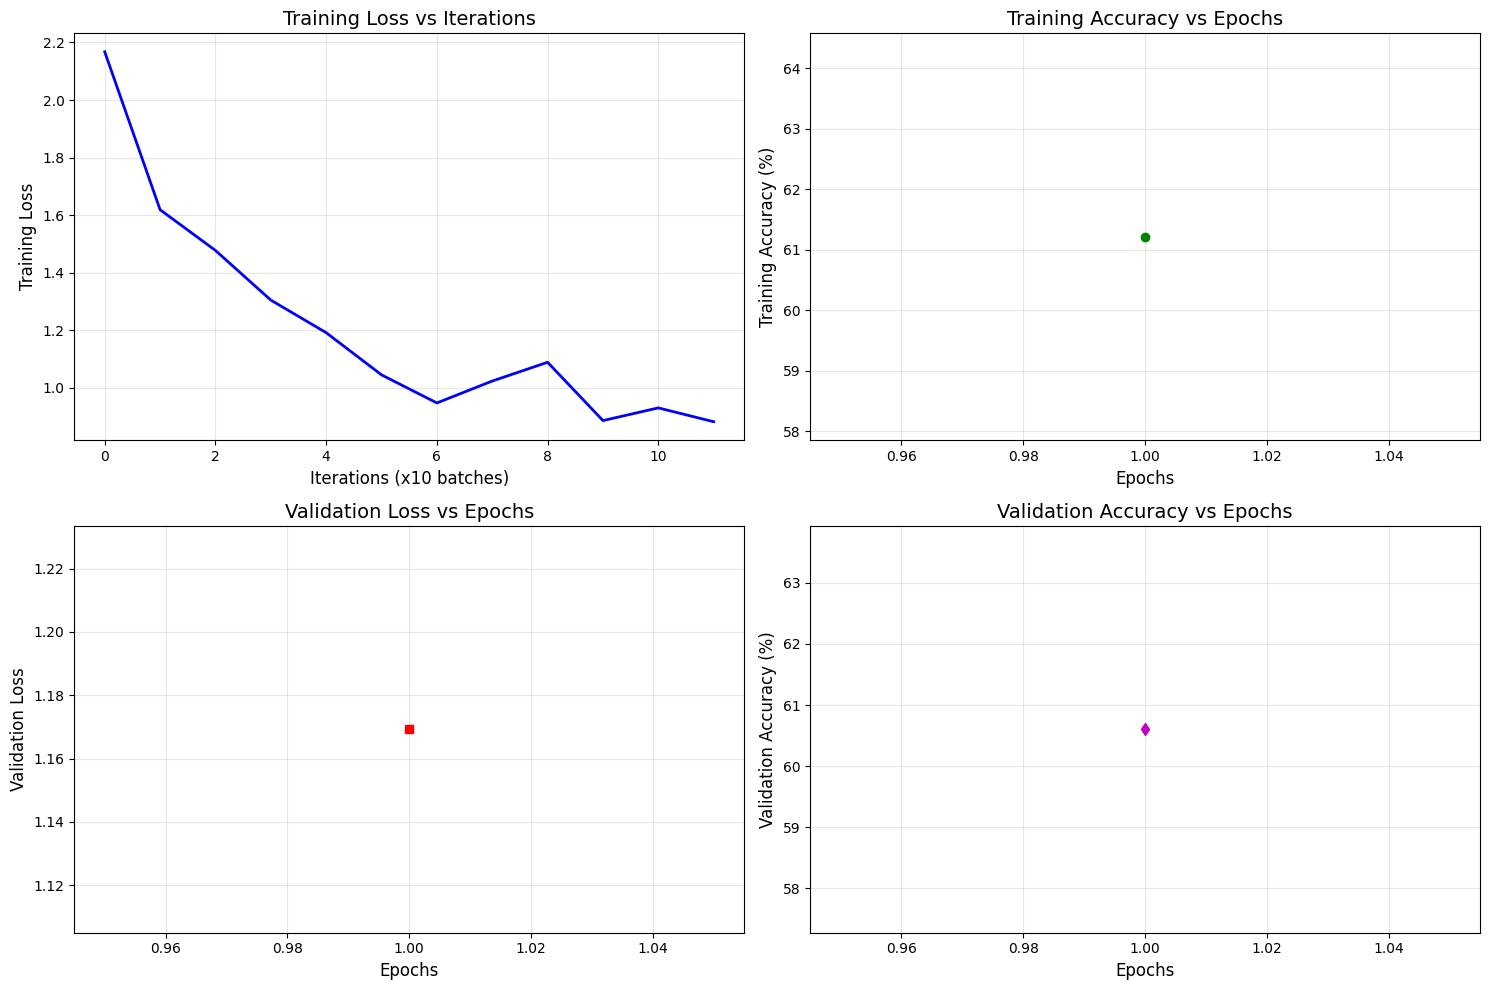


Training completed!
Final Training Accuracy: 61.21%
Final Validation Accuracy: 60.60%


In [ ]:
train(pointnet2, train_loader, valid_loader, 1,  save=True)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
!gdown --id 1VPY_-O9AAxD6BERx1ucQyQ8UJ3nmvvZf

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1VPY_-O9AAxD6BERx1ucQyQ8UJ3nmvvZf
To: /content/Pointnet++/pointnet2_cls.pth
100% 5.91M/5.91M [00:00<00:00, 24.5MB/s]


In [ ]:
in_channels = 6
pointnet2 = pointnet2_cls_ssg(in_channels, NUM_CLASSES)
pointnet2.load_state_dict(torch.load('pointnet2_cls.pth',map_location=torch.device('cpu')))
pointnet2.eval();

In [ ]:
all_preds = []
all_labels = []
val_losses = []
val_accs = []
iterations = []

with torch.no_grad():
    running_correct = 0
    running_total = 0

    for i, data in enumerate(valid_loader):
        print('Batch [%4d / %4d]' % (i+1, len(valid_loader)))

        points, normals, labels = data['pointcloud'].float(), data['normals'].float(), data['category']
        outputs = pointnet2(points, normals)
        _, preds = torch.max(outputs, 1)

        # Calculate batch loss
        batch_loss = loss(outputs, labels)
        val_losses.append(batch_loss.item())

        # Calculate running accuracy
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()
        running_acc = 100. * running_correct / running_total
        val_accs.append(running_acc)
        iterations.append(i)

        # Print batch metrics
        print('Batch loss: %.3f, Running accuracy: %.2f %%' % (batch_loss.item(), running_acc))

        all_preds += list(preds.numpy())
        all_labels += list(labels.numpy())

# Print final metrics
print('-' * 50)
print('Final Validation Accuracy: %.2f %%' % val_accs[-1])
print('Average Validation Loss: %.3f' % (sum(val_losses) / len(val_losses)))

# Plot metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Validation Loss vs Iterations
axes[0].plot(iterations, val_losses, 'r-', linewidth=2)
axes[0].set_xlabel('Iterations (batches)', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].set_title('Validation Loss vs Iterations', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Validation Accuracy vs Iterations
axes[1].plot(iterations, val_accs, 'b-', linewidth=2)
axes[1].set_xlabel('Iterations (batches)', fontsize=12)
axes[1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1].set_title('Validation Accuracy vs Iterations', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Batch [   1 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.282, Running accuracy: 90.62 %
Batch [   2 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.459, Running accuracy: 85.16 %
Batch [   3 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.415, Running accuracy: 85.42 %
Batch [   4 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.088, Running accuracy: 88.67 %
Batch [   5 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 1.017, Running accuracy: 84.06 %
Batch [   6 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.542, Running accuracy: 84.11 %
Batch [   7 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.387, Running accuracy: 84.38 %
Batch [   8 /   14]
SHAPE torch.Size([64, 1024, 3]) torch.Size([64, 1024, 3])
Batch loss: 0.241, Running accuracy: 85.35 %
Batch [   9 /   

In [ ]:
cm = confusion_matrix(all_labels, all_preds);
cm

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

# function from https://deeplizard.com/learn/video/0LhiS6yu2qQ
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
plt.figure(figsize=(8,8))
plot_confusion_matrix(cm, list(classes.keys()), normalize=True)

In [ ]:
plt.figure(figsize=(8,8))
plot_confusion_matrix(cm, list(classes.keys()), normalize=False)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


# Task
The Gradio interface for point cloud classification has been created and launched. You can now upload .off files to get predictions.

## Define Inference Transformations

### Subtask:
Create a `transforms.Compose` sequence specifically for inference. This sequence will include `PointSampler`, `Normalize`, and a custom `InferenceToTensor` class that separates points and normals into two distinct PyTorch tensors. Unlike training, it will not include random data augmentation.


**Reasoning**:
First, I'll define the `InferenceToTensor` class, which will convert the point cloud data and normals into separate PyTorch tensors for inference, as specified in the instructions.



In [ ]:
class InferenceToTensor(object):
    def __call__(self, data):
        assert len(data.shape)==2

        pointcloud = data[:,:3]
        normals = data[:,3:]

        pointcloud_tensor = torch.from_numpy(pointcloud).float()
        normals_tensor = torch.from_numpy(normals).float()

        return pointcloud_tensor, normals_tensor


**Reasoning**:
Now that the `InferenceToTensor` class is defined, I will create the `inference_transforms` pipeline using `transforms.Compose`, including `PointSampler`, `Normalize`, and `InferenceToTensor`, as instructed for inference.



In [ ]:
inference_transforms = transforms.Compose([
                                PointSampler(1024),
                                Normalize(),
                                InferenceToTensor()
                              ])
print("Inference transforms pipeline created.")

## Implement Prediction Function

### Subtask:
Write a `predict_pointcloud` function that takes the path to an `.off` file as input. This function will load the 3D model using `trimesh`, apply the defined inference transformations to generate point cloud and normal tensors, pass them through the loaded `pointnet2` model, and return the predicted class name using the `inv_classes` dictionary.


**Reasoning**:
I will define the `predict_pointcloud` function as described, which will handle loading an `.off` file, applying inference transformations, passing the data through the `pointnet2` model, and returning the predicted class name.



In [ ]:
def predict_pointcloud(off_file_path):
    # Load the 3D model
    mesh = trimesh.load(off_file_path)

    # Apply inference transformations
    pointcloud_tensor, normals_tensor = inference_transforms(mesh)

    # Add batch dimension
    pointcloud_tensor = pointcloud_tensor.unsqueeze(0)
    normals_tensor = normals_tensor.unsqueeze(0)

    # Set model to evaluation mode and make prediction
    pointnet2.eval()
    with torch.no_grad():
        outputs = pointnet2(pointcloud_tensor, normals_tensor)

    # Get predicted class index
    _, predicted_idx = torch.max(outputs, 1)

    # Convert index to class name
    predicted_class_name = inv_classes[predicted_idx.item()]

    return predicted_class_name

print("predict_pointcloud function defined.")

## Create Gradio Interface

### Subtask:
Set up a Gradio interface (`gr.Interface`) with the `predict_pointcloud` function. The input will be a `gr.File` component to upload `.off` files, and the output will be a `gr.Label` component to display the predicted class.


**Reasoning**:
The first step in creating the Gradio interface is to import the `gradio` library, which is typically aliased as `gr`.



In [ ]:
import gradio as gr
print("Gradio library imported.")

Gradio library imported.


**Reasoning**:
With the `gradio` library imported, I will now create the Gradio interface using `gr.Interface()` as specified, setting the `fn` to `predict_pointcloud`, the input to `gr.File` for `.off` files, and the output to `gr.Label`.



In [ ]:
iface = gr.Interface(
    fn=predict_pointcloud,
    inputs=gr.File(file_count='single', file_types=['.off']),
    outputs=gr.Label(),
    title='3D Point Cloud Classifier (ModelNet10)',
    description='Upload an .off file to classify the 3D object into one of 10 categories.'
)

print("Gradio interface created.")

Gradio interface created.


## Launch Gradio App

### Subtask:
Launch the Gradio interface to make it accessible for point cloud classification.


**Reasoning**:
I will launch the Gradio interface using the `.launch()` method to make it accessible.



In [ ]:
iface.launch()

## Final Task

### Subtask:
The Gradio interface for point cloud classification has been created and launched. You can now upload .off files to get predictions.


## Summary:

### Data Analysis Key Findings

*   A custom `InferenceToTensor` class was developed to convert point cloud and normal NumPy arrays into distinct PyTorch float tensors.
*   An `inference_transforms` pipeline was successfully established using `transforms.Compose`, incorporating `PointSampler(1024)`, `Normalize()`, and `InferenceToTensor` for inference-specific preprocessing, excluding data augmentation.
*   The `predict_pointcloud` function was implemented to load `.off` files using `trimesh`, apply the defined inference transformations, perform prediction using the `pointnet2` model, and return the predicted class name.
*   A Gradio interface (`gr.Interface`) was created, linking the `predict_pointcloud` function with a `gr.File` input for `.off` files and a `gr.Label` output for displaying predictions.
*   The Gradio interface was successfully launched, generating a temporary public URL (e.g., `https://81a9f1744897a25959.gradio.live`) for accessing the point cloud classification application.

### Insights or Next Steps

*   The successfully deployed Gradio application provides an interactive and user-friendly way to classify 3D point cloud data from `.off` files.
*   Given the temporary nature of the generated public URL, consider deploying the Gradio application to a more permanent hosting solution for continuous accessibility and broader user engagement.
